In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import re

In [18]:
df=pd.read_csv("/content/tripadvisor_hotel_reviews.csv")

In [19]:
# cheak null values columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20491 entries, 0 to 20490
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  20491 non-null  object
 1   Rating  20491 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 320.3+ KB


In [20]:
df.shape

(20491, 2)

In [21]:
df.head()

,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


In [22]:
df.describe()

,Rating
count,20491.000000
mean,3.952223
std,1.233030
min,1.000000
25%,3.000000
50%,4.000000
75%,5.000000
max,5.000000


In [23]:
df['Rating'].unique()

array([4, 2, 3, 5, 1])

In [24]:
# create function for senstiment

def sentiment(rating):
  if rating >= 4:
    return "Positive"

  elif rating ==3:
    return "Neutral"

  else:
    return "Negative"

In [25]:
df["Sentiment"]=df['Rating'].apply(sentiment)

In [26]:
df.head()

,Review,Rating,Sentiment
0,nice hotel expensive parking got good deal sta...,4,Positive
1,ok nothing special charge diamond member hilto...,2,Negative
2,nice rooms not 4* experience hotel monaco seat...,3,Neutral
3,"unique, great stay, wonderful time hotel monac...",5,Positive
4,"great stay great stay, went seahawk game aweso...",5,Positive


In [27]:
import nltk

nltk.download('stopwords')
nltk.download('punkt')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

TEXT CLEANING

In [28]:
ps = PorterStemmer()

stop_words = set(stopwords.words("english"))

def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z]', ' ', text)

    words = text.split()

    words = [ps.stem(word) for word in words if word not in stop_words]

    return " ".join(words)

df["Clean_Review"] = df["Review"].apply(clean_text)

In [29]:
df.head()


,Review,Rating,Sentiment,Clean_Review
0,nice hotel expensive parking got good deal sta...,4,Positive,nice hotel expens park got good deal stay hote...
1,ok nothing special charge diamond member hilto...,2,Negative,ok noth special charg diamond member hilton de...
2,nice rooms not 4* experience hotel monaco seat...,3,Neutral,nice room experi hotel monaco seattl good hote...
3,"unique, great stay, wonderful time hotel monac...",5,Positive,uniqu great stay wonder time hotel monaco loca...
4,"great stay great stay, went seahawk game aweso...",5,Positive,great stay great stay went seahawk game awesom...


In [30]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df["Clean_Review"])

y = df["Sentiment"]

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [33]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [34]:
y_pred = model.predict(X_test)

In [35]:
accuracy_score(y_test, y_pred)

0.8609416930958771

CONFUSION METRIX

<Axes: >

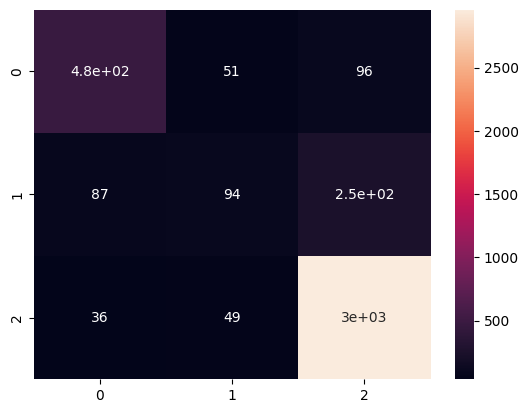

In [40]:
from sklearn.metrics import confusion_matrix
cf=confusion_matrix(y_test,y_pred)
sns.heatmap(cf,annot=True)


In [41]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

    Negative       0.80      0.76      0.78       625
     Neutral       0.48      0.22      0.30       432
    Positive       0.89      0.97      0.93      3042

    accuracy                           0.86      4099
   macro avg       0.72      0.65      0.67      4099
weighted avg       0.84      0.86      0.84      4099



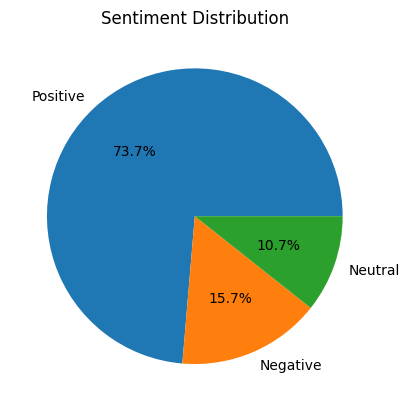

In [42]:
df["Sentiment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Sentiment Distribution")

plt.ylabel("")

plt.show()